# Passo 2 — Exploração e Preparação dos Dados
**Dataset:** Oscar AMPAS — Winner Demographics  
**Objetivo:** Entender a estrutura, tipos de dados, valores ausentes e distribuições.

In [13]:
import sys
print('Python:', sys.executable)
!'{sys.executable}' -m pip install pandas matplotlib -q

Python: c:\Users\bruno\AppData\Local\Python\pythoncore-3.14-64\python.exe


A sintaxe do nome do ficheiro, do nome do diret�rio ou da etiqueta do volume � incorreta.


## 1. Carregamento

In [14]:
import pandas as pd

CAMINHO_CSV = r'C:\Users\bruno\OneDrive\Área de Trabalho\Projetos\projetoFinalDB\world_ampas_oscar_winner_demographics.csv'

df = pd.read_csv(CAMINHO_CSV)
print(f'Shape: {df.shape}')
df.head(5)

Shape: (415, 10)


,name,birth_year,birth_date,birthplace,race_ethnicity,religion,sexual_orientation,year_edition,category,movie
0,Marie Dressler,1868,1868-11-02,"Cobourg, Ontario, Canada",White,NaN,Straight,1931,Best Actress,Min and Bill
1,George Arliss,1868,1868-04-10,"London, England",White,NaN,Straight,1930,Best Actor,Desraeli
2,Edmund Gwenn,1875,1875-09-26,"Vale of Glamorgan, Wales",White,NaN,Na,1948,Best Supporting Actor,Miracle on 34th Street
3,Charles Coburn,1877,1877-06-17,"Savannah, Ga",White,NaN,Straight,1944,Best Supporting Actor,The More the Merrier
4,Lionel Barrymore,1878,1878-04-28,"Philadelphia, Pa",White,Roman Catholic,Straight,1931,Best Actor,A Free Soul


## 2. Estrutura e Tipos

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   name                415 non-null    str  
 1   birth_year          415 non-null    int64
 2   birth_date          414 non-null    str  
 3   birthplace          415 non-null    str  
 4   race_ethnicity      415 non-null    str  
 5   religion            159 non-null    str  
 6   sexual_orientation  415 non-null    str  
 7   year_edition        415 non-null    int64
 8   category            415 non-null    str  
 9   movie               415 non-null    str  
dtypes: int64(2), str(8)
memory usage: 32.6 KB


## 3. Valores Ausentes

In [17]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(1)
pd.DataFrame({'nulos': nulos, 'pct_%': pct}).sort_values('pct_%', ascending=False)

,nulos,pct_%
religion,256,61.7
birth_date,1,0.2
birth_year,0,0.0
name,0,0.0
birthplace,0,0.0
race_ethnicity,0,0.0
sexual_orientation,0,0.0
year_edition,0,0.0
category,0,0.0
movie,0,0.0


## 4. Valores especiais — 'Na' como string

In [18]:
# sexual_orientation usa 'Na' como string em vez de NULL
print('sexual_orientation únicos:', df['sexual_orientation'].unique())
print('Linhas com Na:', (df['sexual_orientation'] == 'Na').sum())

sexual_orientation únicos: <StringArray>
['Straight', 'Na', 'Bisexual', 'Matter of Dispute', 'Gay', 'Lesbian']
Length: 6, dtype: str
Linhas com Na: 10


## 5. Distribuições — colunas categóricas

In [19]:
for col in ['category', 'race_ethnicity', 'sexual_orientation', 'religion']:
    print(f'\n--- {col} ---')
    print(df[col].value_counts(dropna=False))


--- category ---
category
Best Actress               87
Best Actor                 86
Best Director              86
Best Supporting Actor      78
Best Supporting Actress    78
Name: count, dtype: int64

--- race_ethnicity ---
race_ethnicity
White             386
Black              14
Hispanic            8
Asian               4
Multiracial         2
Middle Eastern      1
Name: count, dtype: int64

--- sexual_orientation ---
sexual_orientation
Straight             373
Bisexual              20
Na                    10
Gay                    7
Matter of Dispute      3
Lesbian                2
Name: count, dtype: int64

--- religion ---
religion
NaN                      256
Roman Catholic            57
Jewish                    45
Atheist                   15
Protestant                 5
Baptist                    5
Born-Again Christian       4
Buddhist                   4
Christian Science          3
Deist                      3
Lutheran                   3
Anglican/episcopalian      2
Ch

## 6. Período coberto e cardinalidades

In [20]:
print('Edições:', df['year_edition'].min(), 'a', df['year_edition'].max())
print('Categorias únicas:', df['category'].nunique())
print('Filmes únicos:', df['movie'].nunique())
print('Vencedores únicos:', df['name'].nunique())
print()
df['year_edition'].value_counts().sort_index()

Edições: 1927 a 2014
Categorias únicas: 5
Filmes únicos: 335
Vencedores únicos: 348



year_edition
1927    1
1929    2
1930    5
1931    3
1932    3
       ..
2010    4
2011    5
2012    5
2013    5
2014    4
Name: count, Length: 87, dtype: int64

## 7. Vencedores com mais de um Oscar

In [21]:
multiplos = df['name'].value_counts()
multiplos[multiplos > 1]

name
John Ford               4
Katharine Hepburn       4
Walter Brennan          3
Frank Capra             3
William Wyler           3
Ingrid Bergman          3
Jack Nicholson          3
Meryl Streep            3
Daniel Day-Lewis        3
Frank Lloyd             2
Lewis Milestone         2
Leo McCarey             2
Helen Hayes             2
Spencer Tracy           2
Gary Cooper             2
Melvyn Douglas          2
George Stevens          2
Billy Wilder            2
Fred Zinnemann          2
David Lean              2
Bette Davis             2
Elia Kazan              2
Joseph L. Mankiewicz    2
Luise Rainer            2
Vivien Leigh            2
Robert Wise             2
Anthony Quinn           2
Olivia de Havilland     2
Shelley Winters         2
Peter Ustinov           2
Jason Robards           2
Marlon Brando           2
Jack Lemmon             2
Gene Hackman            2
Clint Eastwood          2
Milos Forman            2
Elizabeth Taylor        2
Michael Caine           2
Maggie 

## 8. Estatísticas — birth_year

In [22]:
df['birth_year'].describe()

count     415.000000
mean     1928.848193
std        25.716376
min      1868.000000
25%      1908.000000
50%      1928.000000
75%      1949.000000
max      1990.000000
Name: birth_year, dtype: float64

## 9. Converter tipos e tratar 'Na'

In [23]:
df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')
df['sexual_orientation'] = df['sexual_orientation'].replace('Na', None)

print('Tipos após conversão:')
print(df.dtypes)
print()
print('Nulls após tratamento:')
print(df.isnull().sum())

Tipos após conversão:
name                             str
birth_year                     int64
birth_date            datetime64[us]
birthplace                       str
race_ethnicity                   str
religion                         str
sexual_orientation               str
year_edition                   int64
category                         str
movie                            str
dtype: object

Nulls após tratamento:
name                    0
birth_year              0
birth_date              1
birthplace              0
race_ethnicity          0
religion              256
sexual_orientation     10
year_edition            0
category                0
movie                   0
dtype: int64


## 10. Distribuição de vencedores por etnia e por década

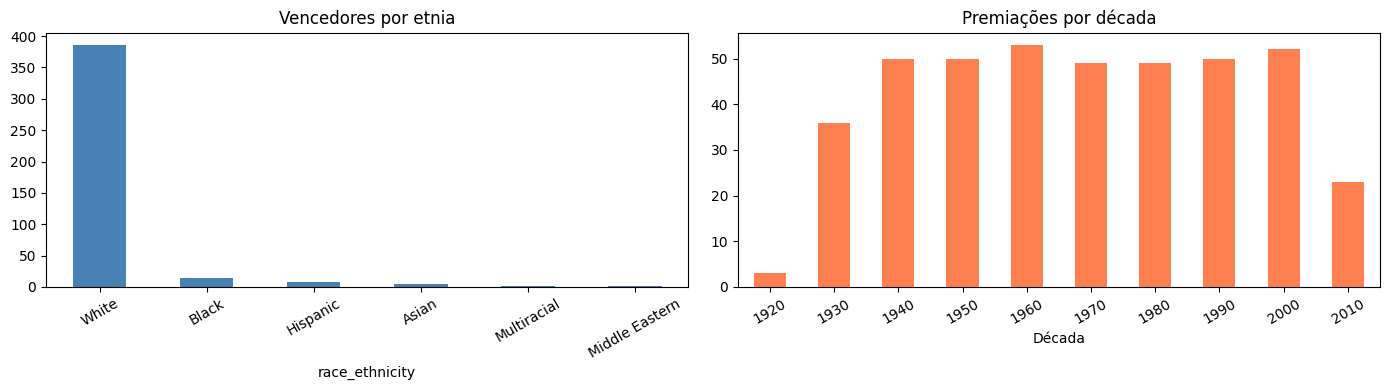

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['race_ethnicity'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Vencedores por etnia')
axes[0].tick_params(axis='x', rotation=30)

df['decada'] = (df['year_edition'] // 10) * 10
df.groupby('decada')['name'].count().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Premiações por década')
axes[1].set_xlabel('Década')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../../Aprendizado/grafico_oscar_exploracao.png', dpi=100)
plt.show()